# Muller-Brown - working!

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'

import sys
sys.path.insert(0, os.path.abspath('..'))

import jax
import jax.numpy as jnp


import matplotlib.pyplot as plt
import optax

import flax
import flax.linen as nn

from omegaconf import OmegaConf

from src.consistency_bridge import ConsistencyBridge

from src.models import ScoreMLP, ConservativeMLP
from src.plotting import plot_trajectories_with_background

## define reference

In [ ]:
beta = 1.0
def muller_brown_potential(z):
    x = z[0]
    y = z[1]
    e1 = -200 * jnp.exp(-(x - 1) ** 2 - 10 * y ** 2)
    e2 = -100 * jnp.exp(-x ** 2 - 10 * (y - 0.5) ** 2)
    e3 = -170 * jnp.exp(-6.5 * (0.5 + x) ** 2 + 11 * (x + 0.5) * (y - 1.5) - 6.5 * (y - 1.5) ** 2)
    e4 = 15.0 * jnp.exp(0.7 * (1 + x) ** 2 + 0.6 * (x + 1) * (y - 1) + 0.7 * (y - 1) ** 2)
    return beta * (e1 + e2 + e3 + e4)

def base_drift(x, t):
    # drift of the base process
    return -jax.grad(muller_brown_potential)(x)

## plot potential

In [4]:
# Define grid for background
grid_res = 40
xlim = (-1.5, 1.0)
ylim = (-0.5, 1.7)
x = jnp.linspace(*xlim, grid_res)
y = jnp.linspace(*ylim, grid_res)
X, Y = jnp.meshgrid(x, y)

# Evaluate potential on the grid
Z = jnp.stack([muller_brown_potential(jnp.array([x_, y_])) for x_, y_ in zip(X.flatten(), Y.flatten())])
Z = Z.reshape(X.shape)

# Save for later use
background_data = {"X": X, "Y": Y, "Z": Z}

## Train Consistency Bridge

In [ ]:
sigma = 3.0 
d = 2 

shape = (d,)

# minima values (from Du et al. 2024)
x_0 = jnp.array([-0.55828035, 1.44169])
x_1 = jnp.array([0.62361133, 0.02804632])

T = 0.05

model = ConservativeMLP(
    dim_hidden=(128, 128),
    emb_dim_hidden=(64, 64),
    activation=nn.gelu,
)

bridge_config = {
        'base_drift': False,
        'guiding_type': 'brownian',
        'decay_coeff': False, 
        'sampler': 'euler',
    }

bridge = ConsistencyBridge(
    shape=shape,
    x_0=x_0,
    x_T=x_1,
    base_drift_fn=base_drift,
    sigma_fn=sigma,
    model=model,
    bridge_config=bridge_config,
    T=T
)

In [6]:
base_drift(x_0, 0.0), base_drift(x_1, 0.0) # should be close to zero

(Array([ 0.06149581, -0.02345026], dtype=float32),
 Array([-0.06324768, -0.04301453], dtype=float32))

In [9]:
train_config = {
    'self_consistency': 'nodrift', # 'standard' or 'nodrift'
    'num_steps': 1000,            # number of discretisation steps
    'num_outer_iterations': 4_000,  # number of outer iterations
    'num_inner_iterations': 1,      # number of inner iterations
    'traj_batch_size': 64,          # number of trajectories per outer iteration
    'train_batch_size': 20_000,       # number of training samples per inner iteration
    'lr': 3e-4, #                    # learning rate
    'ema_rate': 1.0, # ema rate: 1.0 means no ema
    'jacobian_method': 'euler',
    'beta_schedule': 'average', # 'average', 'beta', 'endpoint', 'next_step'
    'ckpt_freq': 200,          # frequency of checkpoints
    'STL_adjustments': False, #False, #True
    'loss_clip': 1e4,
}

key = jax.random.PRNGKey(2)
state, ema_params_lst, ema_grad_norms = bridge.train(key, train_config)

Training: 100%|████████████████████████| 4000/4000 [05:39<00:00, 11.77step/s, loss=7.6811e+02, ema_grad_norm=6.3747e+03]


Training finished.


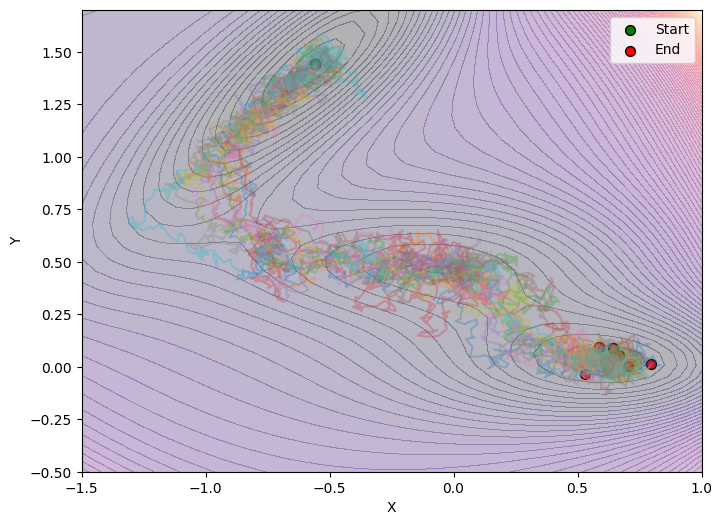

In [10]:
num_trajs = 16
num_steps = 1000
sample_keys = jax.random.split(key, num_trajs)

idx = -1
ema_params = ema_params_lst[idx]  # use the last ema parameters

ts = jnp.linspace(0, T, num_steps + 1)
x_traj, drift_traj, dB_t_traj = jax.vmap(
        bridge.sample_controlled_sde,
        in_axes=(0, None, None)
        )(sample_keys, ema_params, num_steps) # (B,N+1,d), (B,N,d), (B,N,d)

plot_trajectories_with_background(x_traj[:10], background_data, alpha=1.0)